In [1]:
# step 1 - importing libraries

import os
import urllib.request
import zipfile
from pathlib import Path
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Setup successful")
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Setup successful
Torch version: 2.5.1
Torchvision version: 0.20.1


In [2]:
from torchvision import datasets

DATA_PATH = Path("/mnt/nfs/Shared_Linux/Datasets/EuroSAT_RGB")

full_dataset = datasets.ImageFolder(root=DATA_PATH)

image_paths = [s[0] for s in full_dataset.samples]
numeric_labels = full_dataset.targets

In [3]:
#Step 12 — Custom Dataset Class

import torch
from torch.utils.data import Dataset
from PIL import Image

class EuroSATDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:
# Step 11 — Train / Validation / Test Split

from sklearn.model_selection import train_test_split
from collections import Counter

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    numeric_labels,
    test_size=0.3,
    random_state=42,
    stratify=numeric_labels
)

In [5]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [6]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("Train:", Counter(y_train))
print("Validation:", Counter(y_val))
print("Test:", Counter(y_test))

Train: 18900
Validation: 4050
Test: 4050
Train: Counter({7: 2100, 9: 2100, 0: 2100, 1: 2100, 2: 2100, 6: 1750, 4: 1750, 3: 1750, 8: 1750, 5: 1400})
Validation: Counter({9: 450, 2: 450, 1: 450, 0: 450, 7: 450, 3: 375, 4: 375, 6: 375, 8: 375, 5: 300})
Test: Counter({9: 450, 0: 450, 7: 450, 1: 450, 2: 450, 6: 375, 4: 375, 3: 375, 8: 375, 5: 300})


In [7]:
# Step 13 — Data Transforms

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [8]:
# Step 14 — Create Dataset Objects

train_dataset = EuroSATDataset(X_train, y_train, transform=train_transform)
val_dataset   = EuroSATDataset(X_val, y_val, transform=val_test_transform)
test_dataset  = EuroSATDataset(X_test, y_test, transform=val_test_transform)

In [9]:
# Step 15 — DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 64, 64])
torch.Size([64])


In [10]:
import torch
import torch.nn as nn

class IdentityBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.relu = nn.ReLU()

        self.identity = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        residual = x
        x = self.identity(x)
        x += residual
        x = self.relu(x)
        return x


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.relu = nn.ReLU()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels)
        )

        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, 2, 0),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.conv(x)
        x += residual
        x = self.relu(x)
        return x


class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.input = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.stage1 = nn.Sequential(
            IdentityBlock(64),
            IdentityBlock(64)
        )

        self.stage2 = nn.Sequential(
            ConvBlock(64, 128),
            IdentityBlock(128)
        )

        self.stage3 = nn.Sequential(
            ConvBlock(128, 256),
            IdentityBlock(256)
        )

        self.stage4 = nn.Sequential(
            ConvBlock(256, 512),
            IdentityBlock(512)
        )

        self.avgPool = nn.AvgPool2d(8)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*1*1, 256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.input(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgPool(x)
        x = self.fc(x)
        return x

In [11]:
#Plot the loss and accuracy for training and validation
from IPython.display import display

def plot(trainingLoss, validationLoss, trainingAccuracy, validationAccuracy, title):
    ax1.clear()
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_ylim(0, 2.5)

    ax1.plot(trainingLoss, label="Training loss")
    ax1.plot(validationLoss, label="Validation loss")

    ax1.legend()

    ax2.clear()
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 100)

    ax2.plot(trainingAccuracy, label="Training accuracy")
    ax2.plot(validationAccuracy, label="Validation accuracy")

    ax2.legend()

    fig.suptitle(title)

    plotDisplay.update(fig)
    plt.close(fig)

In [12]:
def runEpoch(model, device, dataloader, lossFunction, optimizer, train):
    if train:
        model.train()
        context = torch.enable_grad()
    else:
        model.eval()
        context = torch.no_grad()

    runningLoss = 0.0
    correct = 0
    total = 0

    with context:
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = lossFunction(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            runningLoss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epochLoss = runningLoss / len(dataloader)
    accuracy = 100 * correct / total

    return epochLoss, accuracy

In [13]:
def train(model, device, epochs, optimizer, lossFunction, fileName):
    bestValidationAccuracy = 0

    trainingLossHistory = []
    validationLossHistory = []

    trainingAccuracyHistory = []
    validationAccuracyHistory = []

    for epoch in range(epochs):

        print(f"Epoch {epoch}", end=": ")

        epochTrainingLoss, epochTrainingAccuracy = runEpoch(
            model,
            device,
            train_loader,
            lossFunction,
            optimizer,
            train=True
        )

        trainingLossHistory.append(epochTrainingLoss)
        trainingAccuracyHistory.append(epochTrainingAccuracy)

        print(f"Training Loss: {epochTrainingLoss:.4f}, Training Accuracy: {epochTrainingAccuracy:.2f}%", end=", ")

        epochValidationLoss, epochValidationAccuracy = runEpoch(
            model,
            device,
            val_loader,
            lossFunction,
            optimizer=None,
            train=False
        )

        validationLossHistory.append(epochValidationLoss)
        validationAccuracyHistory.append(epochValidationAccuracy)

        print(f"Validation Loss: {epochValidationLoss:.4f}, Validation Accuracy: {epochValidationAccuracy:.2f}%")

        plot(
            trainingLossHistory,
            validationLossHistory,
            trainingAccuracyHistory,
            validationAccuracyHistory,
            fileName
        )

        if epochValidationAccuracy > bestValidationAccuracy:
            bestValidationAccuracy = epochValidationAccuracy
            torch.save(model.state_dict(), f"Best {fileName}.pth")

    return trainingLossHistory, validationLossHistory, trainingAccuracyHistory, validationAccuracyHistory

In [14]:
#Load the best model and test
def evaluate(model, device, fileName, test_loader, lossFunction):
    model.load_state_dict(torch.load(f"Best {fileName}.pth", weights_only=True))

    testingLoss, testingAccuracy = runEpoch(
        model,
        device,
        test_loader,
        lossFunction,
        optimizer=None,
        train=False
    )

    print(f"Testing Loss: {testingLoss:.4f}, Testing Accuracy: {testingAccuracy:.2f}%")

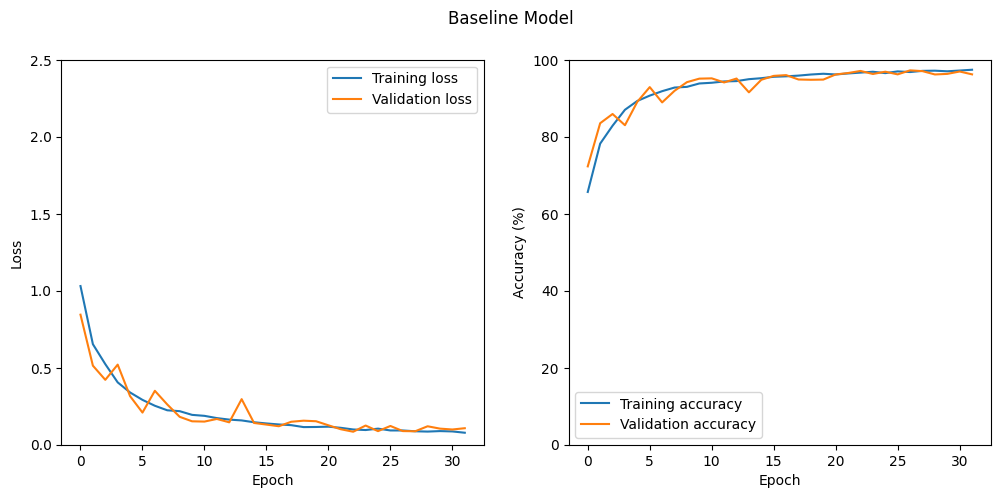

Epoch 0: Training Loss: 1.0303, Training Accuracy: 65.65%, Validation Loss: 0.8444, Validation Accuracy: 72.30%
Epoch 1: Training Loss: 0.6528, Training Accuracy: 78.20%, Validation Loss: 0.5134, Validation Accuracy: 83.51%
Epoch 2: Training Loss: 0.5234, Training Accuracy: 82.85%, Validation Loss: 0.4214, Validation Accuracy: 85.90%
Epoch 3: Training Loss: 0.4049, Training Accuracy: 87.00%, Validation Loss: 0.5201, Validation Accuracy: 82.99%
Epoch 4: Training Loss: 0.3393, Training Accuracy: 89.30%, Validation Loss: 0.3154, Validation Accuracy: 89.09%
Epoch 5: Training Loss: 0.2912, Training Accuracy: 90.68%, Validation Loss: 0.2088, Validation Accuracy: 92.89%
Epoch 6: Training Loss: 0.2530, Training Accuracy: 91.83%, Validation Loss: 0.3501, Validation Accuracy: 88.91%
Epoch 7: Training Loss: 0.2236, Training Accuracy: 92.77%, Validation Loss: 0.2614, Validation Accuracy: 91.93%
Epoch 8: Training Loss: 0.2179, Training Accuracy: 92.95%, Validation Loss: 0.1812, Validation Accuracy:

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Model().to(device)

plt.close('all')

plt.ion()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plotDisplay = display(fig, display_id=True)

NB_EPOCHS = 32

import torch.optim as optim

baselineTrainingLoss, baselineValidationLoss, baselineTrainingAccuracy, baselineValidationAccuracy = train(
    model,
    device,
    epochs = NB_EPOCHS,
    optimizer = optim.Adam(model.parameters(), lr=0.0001),
    lossFunction = nn.CrossEntropyLoss(),
    fileName = "Baseline Model",
)

In [16]:
evaluate(
    model,
    device,
    "Baseline Model",
    test_loader,
    lossFunction = nn.CrossEntropyLoss(),
)

Testing Loss: 0.0978, Testing Accuracy: 97.06%
